# Predictive Banking Marketing Intelligence

## Introduction
A Portuguese bank used phone campaigns to promote term deposits. In the dataset for this project, only <b>11.27% of recorded contacts</b> resulted in a subscription. Because every call takes an agent’s time, the bank has a practical question: <b>which customers should it prioritize, and when should it stop calling?</b>

Our goal is to build a targeting strategy using information available <b><u>before a call is placed</b></u>. We will estimate each customer’s probability of subscribing, rank customers by that probability, and compare the results with calling customers at random. We will then use an explicit assumption about the cost of a call and the value of a subscription to recommend a calling cutoff.

## Dataset

We will use the <u>bank-additional-full.csv</u> from the <b>UCI Bank Marketing dataset</b>. It contains <b>41,188 records, 20 predictor variables</b>, and one target variable, y, which indicates whether the client subscribed to a term deposit. The records come from campaigns conducted between May 2008 and November 2010.

The predictors describe customer characteristics, loans and credit status, campaign contacts, previous campaign history, and economic conditions. Each row describes a recorded campaign contact; it should not automatically be treated as a unique customer.

# Data Analysis and Modeling

## Dependencies and Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading 

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Exploratory Data Analysis

In [3]:
df.info() # shows no nulls

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

<b> Analysis and Explanation: </b><br>
The dataset contains 41,188 records and 21 columns: 20 predictors and the target variable, y. Every column has 41,188 non-null entries, so there are no null values recorded in the DataFrame

The duration feature records the length of the call in seconds. Our model is intended to prioritize customers before a call is placed, so call duration would not be available when making a prediction. Including it would introduce data leakage: the model would learn from information collected after the decision it is meant to support. We will exclude duration from the predictive features.

In [4]:
category_summary = (
    df.select_dtypes(include = ["object", "string"])
      .melt(var_name = "column", value_name = "value")
      .groupby(["column", "value"], dropna=False)
      .size()
      .reset_index(name = "count")
)

category_summary["percent"] = (
    category_summary["count"]
    / category_summary.groupby("column")["count"].transform("sum")
    * 100
).round(1)

category_summary = category_summary.sort_values(
    ["column", "count"], ascending=[True, False]
)

category_summary

,column,value,count,percent
0,contact,cellular,26144,63.5
1,contact,telephone,15044,36.5
4,day_of_week,thu,8623,20.9
3,day_of_week,mon,8514,20.7
6,day_of_week,wed,8134,19.7
5,day_of_week,tue,8090,19.6
2,day_of_week,fri,7827,19.0
7,default,no,32588,79.1
8,default,unknown,8597,20.9
9,default,yes,3,0.0


<b>Analysis and Explanation: </b><br>
Although every column is non-null, six categorical columns contain the value <b>"unknown"</b>: default, education, housing, loan, job, and marital. It appears most often in default, with 8,597 records (20.9%), followed by education, with 1,731 records (4.2%). The other four columns each have "unknown" in fewer than 3% of records.

We will keep <b>"unknown"</b> as a separate category rather than replace it with "no" or remove those records. This preserves the information that the value was unavailable, especially in default, where "unknown" accounts for 20.9% of records.

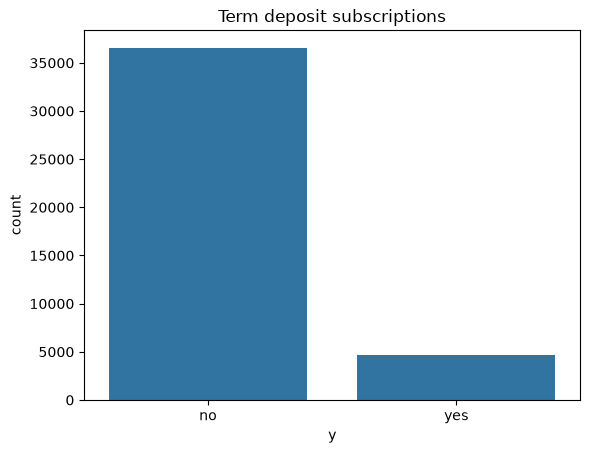

In [5]:
counts = df["y"].value_counts()
percentages = df["y"].value_counts(normalize = True).mul(100).round(1)

pd.DataFrame({"count": counts, "percent": percentages})

sns.countplot(data = df, x= "y", order=["no", "yes"])
plt.title("Term deposit subscriptions")
plt.show()

<b> Analysis and Explanation: </b><br>
Of the 41,188 recorded contacts, 36,548 (88.7%) did not result in a term deposit subscription, while 4,640 (11.3%) did. The chart shows that "no" is much more common than "yes", so the target variable is imbalanced.

## Numeric Predictor Overview

In [6]:
df.drop(columns="duration").describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


<b>Analysis and Explanation </b><br>
Customers have a median age of 38. Most had few current-campaign contacts (median 2), though the maximum of 56 suggests a long upper tail. At least 75% had no prior-campaign contacts (previous = 0). The pdays quartiles are all 999, a code for no previous contact, so its mean should not be read as a typical number of days. The remaining columns summarize economic conditions on different scales.

## Investigating pdays

In [7]:
df["pdays"].value_counts().head(10)

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
Name: count, dtype: int64

In [8]:
print(
    "Percent with pdays = 999:",
    round((df["pdays"] == 999).mean() * 100, 1)
)

Percent with pdays = 999: 96.3


<b>Analysis and Explanation </b><br>
In 96.3% of records, pdays = 999, indicating no contact in a previous campaign. Only 3.7% have a recorded number of days since prior contact. This explains why all three quartiles are 999 and why the mean does not represent a meaningful waiting time.

## Feature Engineering: pdays

In [9]:
df_model = df.copy()

# 1 = contacted in a previous campaign; 0 = not contacted
df_model["previously_contacted"] = (df_model["pdays"] != 999).astype(int)

# Keep actual day counts; use 0 where no prior contact exists
df_model["days_since_previous_contact"] = (
    df_model["pdays"].where(df_model["pdays"] != 999, 0)
)

df_model = df_model.drop(columns="pdays")

df_model[["previously_contacted", "days_since_previous_contact"]].head()

,previously_contacted,days_since_previous_contact
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


<b>Analysis and Explanation </b><br>
Because pdays = 999 means no contact in a previous campaign, we replaced pdays with two features. previously_contacted records whether a prior contact occurred, while days_since_previous_contact retains the day count when one is available. This prevents the model from interpreting 999 as an actual number of days.

## Age and Contact Distributions

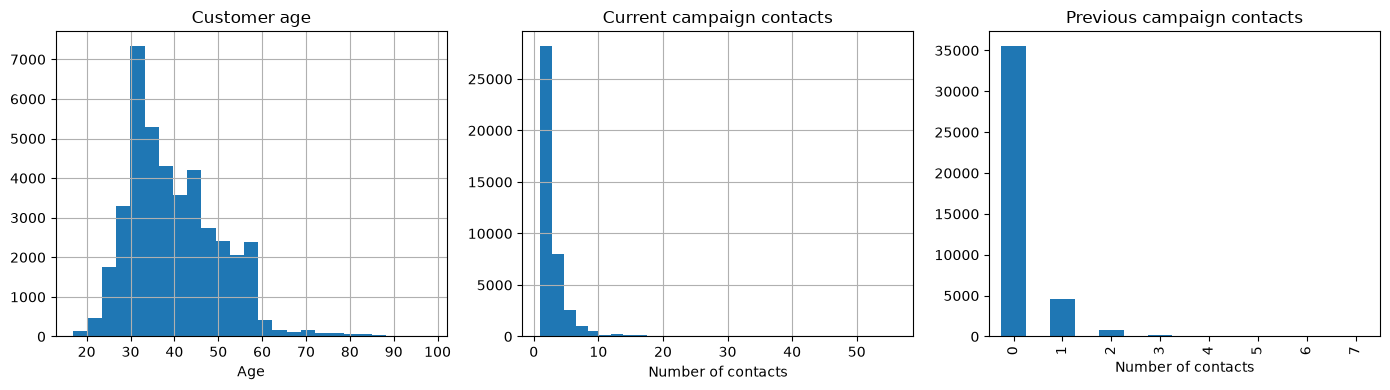

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

df_model["age"].hist(bins = 25, ax=axes[0])
axes[0].set_title("Customer age")
axes[0].set_xlabel("Age")

df_model["campaign"].hist(bins = 30, ax = axes[1])
axes[1].set_title("Current campaign contacts")
axes[1].set_xlabel("Number of contacts")

df_model["previous"].value_counts().sort_index().plot.bar(ax = axes[2])
axes[2].set_title("Previous campaign contacts")
axes[2].set_xlabel("Number of contacts")

plt.tight_layout()
plt.show()

<b>Analysis and Explanation</b><br>
Most recorded customers are between roughly 30 and 60 years old, with relatively few at older ages. Current-campaign contacts are strongly right-skewed: most records involve only a few contacts, while a small number involve many more. Previous-campaign contacts are concentrated at zero, consistent with the earlier finding that most records have no prior contact history. These plots show unusual high contact counts, but do not establish that those values are errors.

## Predictor Correlations

In [11]:
X_eda = df_model.drop(columns = ["y", "duration"])

# One-hot encode categorical columns for this EDA calculation
X_eda = pd.get_dummies(X_eda, dtype=int)

y_eda = (df_model["y"] == "yes").astype(int)

scores = X_eda.corrwith(y_eda)

ranked_scores = scores.reindex(
    scores.abs().sort_values(ascending=False).index
).round(3)

print(ranked_scores.to_string())

nr.employed                     -0.355
previously_contacted             0.325
poutcome_success                 0.316
euribor3m                       -0.308
emp.var.rate                    -0.298
days_since_previous_contact      0.267
previous                         0.230
poutcome_nonexistent            -0.194
contact_cellular                 0.145
contact_telephone               -0.145
month_mar                        0.144
month_oct                        0.137
cons.price.idx                  -0.136
month_sep                        0.126
month_may                       -0.108
default_no                       0.099
default_unknown                 -0.099
job_student                      0.094
job_retired                      0.092
month_dec                        0.079
month_apr                        0.076
job_blue-collar                 -0.074
campaign                        -0.066
cons.conf.idx                    0.055
marital_single                   0.054
education_university.degr

<b>Explanation and Analysis</b>
The strongest individual associations with subscription are nr.employed (−0.355), previously_contacted (0.325), poutcome_success (0.316), euribor3m (−0.308), and emp.var.rate (−0.298). This shows that prior campaign history and economic conditions are prominent in the correlation results.

days_since_previous_contact has a positive correlation of 0.267, but that score also reflects the placeholder value of zero assigned to records with no prior contact. Most demographic and loan categories have correlations close to zero. Each score describes one encoded feature on its own; it does not show whether that feature will improve a predictive model.

## Feature Engineering
*Feature engineering and EDA #2 by Mason Delan*

This builds on df_model from EDA #1, which already has the pdays split. The cell below:

1. Removes the 12 exact duplicate rows from our proposal, before dropping duration so only true copies count
2. Makes y 1 for yes and 0 for no, and drops duration since it is only known after the call
3. Merges default = yes (3 rows) into unknown and education = illiterate (18 rows) into basic.4y, since they are too small to use
4. Adds age_group, since age had only a 0.030 correlation with y even though students and retirees subscribe the most (raw age stays for tree models)
5. Caps campaign at 10, since it is very right skewed (median 2, max 56) and EDA #1 found no sign the high counts are errors

I did not add the financial obligation indicator from our framework, since housing and loan were close to 0 correlation with y in EDA #1.

In [12]:
# remove exact duplicates first, while duration is still there
print("Exact duplicate rows:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates().reset_index(drop=True)

# target as 1 and 0, and duration removed
df_model["y"] = (df_model["y"] == "yes").astype(int)
df_model = df_model.drop(columns="duration")

# merge categories that are almost empty
df_model["default"] = df_model["default"].replace("yes", "unknown")
df_model["education"] = df_model["education"].replace("illiterate", "basic.4y")

# age groups
age_bins = [0, 24, 39, 59, 120]
age_labels = ["under 25", "25 to 39", "40 to 59", "60 and over"]
df_model["age_group"] = pd.cut(df_model["age"], bins=age_bins, labels=age_labels)

# cap campaign at 10
print("Rows with more than 10 contacts:", (df_model["campaign"] > 10).sum())
df_model["campaign_capped"] = df_model["campaign"].clip(upper=10)
df_model = df_model.drop(columns="campaign")

print("Shape:", df_model.shape)
print(f"Subscription rate: {df_model['y'].mean() * 100:.2f}%")

Exact duplicate rows: 12
Rows with more than 10 contacts: 869
Shape: (41176, 22)
Subscription rate: 11.27%


<b>Analysis and Explanation</b><br>
df_model now has 41,176 rows, 21 predictors, and y, and the subscription rate stays at 11.27%. Only 869 rows had more than 10 contacts, so the cap barely changes the data. Encoding and scaling are left for after the split, fit on the training data only.

## EDA #2
EDA #2 checks if the new features are related to subscribing, if any features overlap too much, and if there is anything the train and test split should know.

age_group
under 25       24.0
25 to 39       11.1
40 to 59        8.8
60 and over    39.6
Name: y, dtype: float64
campaign_capped
1     13.0
2     11.5
3     10.7
4      9.4
5      7.5
6      7.7
7      6.0
8      4.2
9      6.0
10     3.6
Name: y, dtype: float64


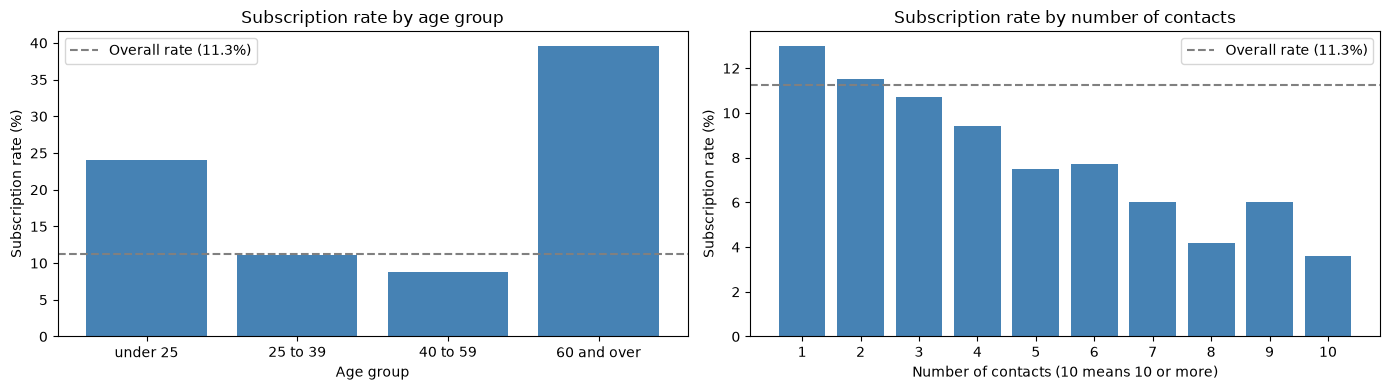

In [13]:
# subscription rate by age group and by number of contacts
overall_rate = df_model["y"].mean() * 100
age_rate = (df_model.groupby("age_group", observed=True)["y"].mean() * 100).round(1)
contact_rate = (df_model.groupby("campaign_capped")["y"].mean() * 100).round(1)
print(age_rate)
print(contact_rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(age_rate.index.astype(str), age_rate, color="steelblue")
axes[0].set_title("Subscription rate by age group")
axes[0].set_xlabel("Age group")
axes[1].bar(contact_rate.index.astype(str), contact_rate, color="steelblue")
axes[1].set_title("Subscription rate by number of contacts")
axes[1].set_xlabel("Number of contacts (10 means 10 or more)")
for ax in axes:
    ax.axhline(overall_rate, color="gray", linestyle="--",
               label=f"Overall rate ({overall_rate:.1f}%)")
    ax.set_ylabel("Subscription rate (%)")
    ax.legend()
plt.tight_layout()
plt.show()

<b>Analysis and Explanation</b><br>
Age is high at both ends and low in the middle (24.0% under 25 and 39.6% at 60 and over, versus 11.1% and 8.8% in between), which is why age barely correlated with y in EDA #1. The rate also mostly drops as contacts go up, from 13.0% at one contact to 3.6% at 10 or more. That matters for when to stop calling, though customers who need many calls may just be less interested.

In [14]:
# how previously_contacted lines up with poutcome
prev = df_model.groupby(["poutcome", "previously_contacted"])["y"].agg(["count", "mean"])
prev.columns = ["rows", "rate"]
prev["rate"] = (prev["rate"] * 100).round(1)
print(prev)
print("Rows with previous above 0:", (df_model["previous"] > 0).sum())
print("Rows with previously_contacted = 1:", df_model["previously_contacted"].sum())

                                   rows  rate
poutcome    previously_contacted             
failure     0                      4110  12.9
            1                       142  51.4
nonexistent 0                     35551   8.8
success     1                      1373  65.1
Rows with previous above 0: 5625
Rows with previously_contacted = 1: 1515


<b>Analysis and Explanation</b><br>
EDA #1 treated pdays = 999 as no previous contact. But 5,625 rows have previous above 0 and only 1,515 have previously_contacted = 1, because 4,110 customers from failed earlier campaigns still have pdays = 999. So previously_contacted really means the bank has a date for the last contact (mostly previous successes, 1,373 of 1,515). Previous successes still subscribe at 65.1%, versus 8.8% for customers with no earlier campaign.

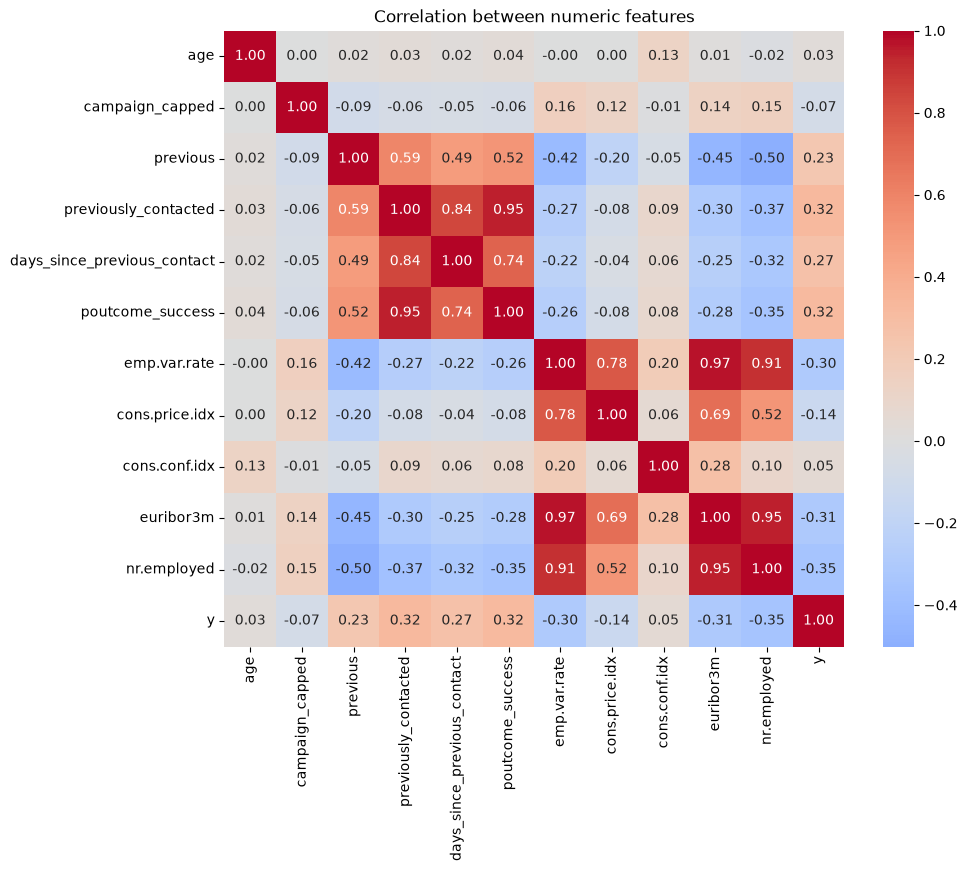

In [15]:
# correlation between the numeric features
corr_data = df_model.copy()
corr_data["poutcome_success"] = (corr_data["poutcome"] == "success").astype(int)

corr_cols = ["age", "campaign_capped", "previous", "previously_contacted",
             "days_since_previous_contact", "poutcome_success", "emp.var.rate",
             "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y"]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()

<b>Analysis and Explanation</b><br>
Two groups of features move almost together:

* Economic: emp.var.rate, euribor3m, and nr.employed (0.91 to 0.97)
* Previous campaign: previously_contacted with poutcome_success (0.95) and days_since_previous_contact (0.84)

All five of the strongest features from EDA #1 are in these groups, so some of that signal is repeated. For logistic regression we should keep only one economic variable (nr.employed is strongest with y at -0.35). Tree models are not hurt as much.

In [16]:
# the rows are in date order, so five equal parts in order work like five time periods
time_part = pd.qcut(df_model.index, 5, labels=["1st", "2nd", "3rd", "4th", "5th"])
time_table = df_model.groupby(time_part, observed=True).agg(
    rate=("y", "mean"), euribor3m=("euribor3m", "mean"))
time_table["rate"] = (time_table["rate"] * 100).round(1)
time_table.round(2)

,rate,euribor3m
1st,3.1,4.86
2nd,5.4,4.95
3rd,5.9,4.90
4th,11.1,2.36
5th,30.8,1.03


<b>Analysis and Explanation</b><br>
The UCI page says the rows are in date order (May 2008 to November 2010). Across the five parts, the subscription rate climbs from 3.1% to 30.8% while euribor3m drops from 4.86 to 1.03. So the economic variables partly describe when the call was made, like our proposal warned. We should still compare models with and without them, and a time ordered split will look very different from a random one.

In [17]:
# save the engineered dataset for the train and test split step
print("Missing values:", df_model.isna().sum().sum())
df_model.to_csv("bank_features.csv", index=False)

Missing values: 0


## Summary and Notes for the Next Steps

* bank_features.csv (same as df_model): 41,176 rows, 21 predictors, and y (11.27% subscribed)
* Encode and scale after the split, fit on the training data only, and stratify on y
* For logistic regression, keep only one of emp.var.rate, euribor3m, and nr.employed
* previously_contacted = 0 does not mean never contacted, just no recorded date
* The rows are still in date order if we want the time ordered split